In [1]:
!hdfs dfs -D dfs.replication=1 -cp -f data/*.jsonl hdfs://nn:9000/
!hdfs dfs -D dfs.replication=1 -cp -f data/*.csv hdfs://nn:9000/

In [2]:
from pyspark.sql import SparkSession
spark = (SparkSession.builder.appName("cs544")
         .master("spark://boss:7077")
         .config("spark.executor.memory", "1G")
         .config("spark.sql.warehouse.dir", "hdfs://nn:9000/user/hive/warehouse")
         .enableHiveSupport()
         .getOrCreate())

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/12 04:27:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
problems_df = spark.read.json("hdfs://nn:9000/problems.jsonl")
problems_df.limit(5).show()
spark.sql("DROP TABLE IF EXISTS problems")
problems_df.write.mode("overwrite").saveAsTable("problems")

+-------------+--------+---------+---------+---------------+----------+---------------+-------------------------+------------------+--------------------+-------------+----------+------------+------+----------+
|cf_contest_id|cf_index|cf_points|cf_rating|        cf_tags|difficulty|generated_tests|is_description_translated|memory_limit_bytes|                name|private_tests|problem_id|public_tests|source|time_limit|
+-------------+--------+---------+---------+---------------+----------+---------------+-------------------------+------------------+--------------------+-------------+----------+------------+------+----------+
|          322|       A|    500.0|     1000|            [0]|         7|             93|                    false|         256000000|322_A. Ciel and D...|           45|         1|           2|     2|         1|
|          760|       D|   1000.0|     1600|         [1, 2]|        10|             51|                    false|         256000000|  760_D. Travel Card|       

25/11/12 04:28:12 WARN HiveConf: HiveConf of name hive.stats.jdbc.timeout does not exist
25/11/12 04:28:12 WARN HiveConf: HiveConf of name hive.stats.retries.wait does not exist
25/11/12 04:28:14 WARN ObjectStore: Version information not found in metastore. hive.metastore.schema.verification is not enabled so recording the schema version 2.3.0
25/11/12 04:28:14 WARN ObjectStore: setMetaStoreSchemaVersion called but recording version is disabled: version = 2.3.0, comment = Set by MetaStore UNKNOWN@172.19.0.3
25/11/12 04:28:14 WARN ObjectStore: Failed to get database global_temp, returning NoSuchObjectException
25/11/12 04:28:16 WARN SessionState: METASTORE_FILTER_HOOK will be ignored, since hive.security.authorization.manager is set to instance of HiveAuthorizerFactory.
25/11/12 04:28:16 WARN HiveConf: HiveConf of name hive.internal.ss.authz.settings.applied.marker does not exist
25/11/12 04:28:16 WARN HiveConf: HiveConf of name hive.stats.jdbc.timeout does not exist
25/11/12 04:28:16 W

In [4]:
spark.table("problems").count()

8573

In [5]:
spark.conf.get("spark.sql.warehouse.dir")

'hdfs://nn:9000/user/hive/warehouse'

In [6]:
solutions_df = spark.read.json("hdfs://nn:9000/solutions.jsonl")
solutions_df.limit(5).show(truncate=False)
solutions_df.write \
    .bucketBy(4, "language") \
    .sortBy("language") \
    .mode("overwrite") \
    .saveAsTable("solutions")
spark.table("solutions").count()

+----------+--------+----------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

103672

In [7]:
languages_df     = spark.read.csv("hdfs://nn:9000/languages.csv",     header=True, inferSchema=True)
problem_tests_df = spark.read.csv("hdfs://nn:9000/problem_tests.csv", header=True, inferSchema=True)
sources_df       = spark.read.csv("hdfs://nn:9000/sources.csv",       header=True, inferSchema=True)
tags_df          = spark.read.csv("hdfs://nn:9000/tags.csv",          header=True, inferSchema=True)

languages_df.createOrReplaceTempView("languages")
problem_tests_df.createOrReplaceTempView("problem_tests")
sources_df.createOrReplaceTempView("sources")
tags_df.createOrReplaceTempView("tags")

In [8]:
spark.sql("SHOW TABLES").show(truncate=False)
print("Temporary views:", [t.name for t in spark.catalog.listTables() if t.isTemporary])

+---------+-------------+-----------+
|namespace|tableName    |isTemporary|
+---------+-------------+-----------+
|default  |problems     |false      |
|default  |solutions    |false      |
|         |languages    |true       |
|         |problem_tests|true       |
|         |sources      |true       |
|         |tags         |true       |
+---------+-------------+-----------+

Temporary views: ['languages', 'problem_tests', 'sources', 'tags']


In [9]:
spark.catalog.listTables()

[Table(name='problems', catalog='spark_catalog', namespace=['default'], description=None, tableType='MANAGED', isTemporary=False),
 Table(name='solutions', catalog='spark_catalog', namespace=['default'], description=None, tableType='MANAGED', isTemporary=False),
 Table(name='languages', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True),
 Table(name='problem_tests', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True),
 Table(name='sources', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True),
 Table(name='tags', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True)]

In [10]:
#q1
problems_rdd = spark.table("problems").rdd
problem_tests_rdd = spark.table("problem_tests").rdd

filtered_problems_rdd = problems_rdd.filter(
    lambda row: row.cf_rating is not None and row.cf_rating >= 1600 and "_A." in row.name)

joined_rdd = (
    filtered_problems_rdd.map(lambda row: (row.problem_id, row))
    .join(problem_tests_rdd.map(lambda row: (row.problem_id, row)))
    .filter(lambda x: x[1][1].is_private))

rdd_count = joined_rdd.keys().distinct().count()
problems_df = spark.table("problems")
problem_tests_df = spark.table("problem_tests")

filtered_df = (
    problems_df
    .filter((problems_df.cf_rating >= 1600) & (problems_df.name.contains("_A.")))
    .join(problem_tests_df, "problem_id")
    .filter(problem_tests_df.is_private == True))

dataframe_count = filtered_df.select("problem_id").distinct().count()
sql_query = """
SELECT COUNT(DISTINCT p.problem_id) AS cnt
FROM problems p
JOIN problem_tests t
  ON p.problem_id = t.problem_id
WHERE p.cf_rating >= 1600
  AND p.name LIKE '%_A.%'
  AND t.is_private = true
"""
sql_count = spark.sql(sql_query).collect()[0]["cnt"]
(rdd_count, dataframe_count, sql_count)

(217, 217, 217)

In [11]:
#q2
answer_q2_sql = spark.sql("""
  SELECT COUNT(*) AS c
  FROM solutions AS s
  INNER JOIN problems AS p ON s.problem_id = p.problem_id
  INNER JOIN sources  AS s ON p.source = s.source
  WHERE UPPER(s.language) = 'PYTHON3'
    AND UPPER(s.source_name) = 'CODEFORCES'
    AND s.is_correct = TRUE
""").first()["c"]

answer_q2_sql

10576

In [12]:
#q3 
sql_query_q_difficulty = """
SELECT
  CASE
    WHEN difficulty <= 5 THEN 'Easy'
    WHEN difficulty <= 10 THEN 'Medium'
    ELSE 'Hard'
  END AS difficulty_category,
  COUNT(*) AS count
FROM problems
GROUP BY difficulty_category
ORDER BY difficulty_category
"""
difficulty_counts_df = spark.sql(sql_query_q_difficulty)
difficulty_counts = {row.difficulty_category: row['count'] for row in difficulty_counts_df.collect()}
print(difficulty_counts)

{'Easy': 409, 'Hard': 2396, 'Medium': 5768}


In [13]:
#q4 
tables_status = {}
for table in spark.catalog.listTables():
    tables_status[table.name] = table.isTemporary
print(tables_status)

{'problems': False, 'solutions': False, 'languages': True, 'problem_tests': True, 'sources': True, 'tags': True}


In [14]:
#q5
query_plan_explain = """
SELECT language, COUNT(*) FROM solutions GROUP BY language
"""
spark.sql(query_plan_explain).explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[language#250], functions=[count(1)])
   +- HashAggregate(keys=[language#250], functions=[partial_count(1)])
      +- FileScan parquet spark_catalog.default.solutions[language#250] Batched: true, Bucketed: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[hdfs://nn:9000/user/hive/warehouse/solutions], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<language:string>, SelectedBucketsCount: 4 out of 4




In [15]:
#q6
import time
from pyspark.sql.functions import avg

filtered_problem_tests_df = problem_tests_df.filter(problem_tests_df.is_generated == False)
start_time = time.time()
avg_chars_no_cache = filtered_problem_tests_df.agg(avg("input_chars"), avg("output_chars")).collect()
time_no_cache = time.time() - start_time
filtered_problem_tests_df.cache()

start_time = time.time()
avg_chars_after_cache_call = filtered_problem_tests_df.agg(avg("input_chars"), avg("output_chars")).collect()
time_after_cache_call = time.time() - start_time

start_time = time.time()
avg_chars_cached = filtered_problem_tests_df.agg(avg("input_chars"), avg("output_chars")).collect()
time_cached = time.time() - start_time

filtered_problem_tests_df.unpersist()
[time_no_cache, time_after_cache_call, time_cached]

[0.6499314308166504, 1.1419556140899658, 0.2274327278137207]

In [16]:
!pip install google-genai==0.2.2

In [17]:
from google import genai
import os, re

client = genai.Client(api_key=os.environ['GEMINI_API_KEY'])

def human_query(english_question):
    tables = {
        'problems': ['id', 'name', 'difficulty', 'cf_rating', 'private_tests'],
        'solutions': ['solution_id', 'problem_id', 'language', 'source', 'is_correct'],
        'languages': ['language', 'language_name'],
        'problem_tests': ['test_id', 'problem_id', 'is_generated', 'input_chars', 'output_chars'],
        'sources': ['source_id', 'source_name'],
        'tags': ['tag_id', 'tag_name']
    }

    prompt = f"""
    Using the following question, generate a valid Spark SQL query. Please do not use any formatting. Just return the raw SQL query without any extra content.

    Question: {english_question}

    The schema for the tables is as follows:
    problems: {tables['problems']}
    solutions: {tables['solutions']}
    languages: {tables['languages']}
    problem_tests: {tables['problem_tests']}
    sources: {tables['sources']}
    tags: {tables['tags']}
    """
    
    response = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=prompt,
        config={'temperature': 0}
    )

    generated_query = response.text.strip()

    if generated_query.startswith("```sql") and generated_query.endswith("```"):
        generated_query = generated_query[6:-3].strip()

    generated_query = generated_query.replace('l.language_id = s.language', 'l.language = s.language')

    result = spark.sql(generated_query).collect()
    return result[0][0]

In [18]:
#q7
print(human_query("How many JAVA solutions are there?"))

28722


In [19]:
#q8
print(human_query("What is the maximum memory limit in bytes?"))

1024000000


In [20]:
#q9
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml import Pipeline

cf_df = problems_df.filter(problems_df['source'] == 2)
train_df = cf_df.filter((cf_df['cf_rating'] > 0) & (cf_df['problem_id'] % 2 == 0))
test_df = cf_df.filter((cf_df['cf_rating'] > 0) & (cf_df['problem_id'] % 2 == 1))
missing_df = cf_df.filter(cf_df['cf_rating'] == 0)

features = ['difficulty', 'time_limit', 'memory_limit_bytes']
assembler = VectorAssembler(inputCols=features, outputCol="features")
dt = DecisionTreeRegressor(labelCol='cf_rating', featuresCol='features', maxDepth=5)
pipeline = Pipeline(stages=[assembler, dt])
model = pipeline.fit(train_df)
predictions = model.transform(missing_df)

print((train_df.select("cf_rating").agg({"cf_rating": "avg"}).collect()[0][0], test_df.select("cf_rating").agg({"cf_rating": "avg"}).collect()[0][0], predictions.select("prediction").agg({"prediction": "avg"}).collect()[0][0]))

(1887.9377431906614, 1893.1106471816283, 1950.4728638818783)


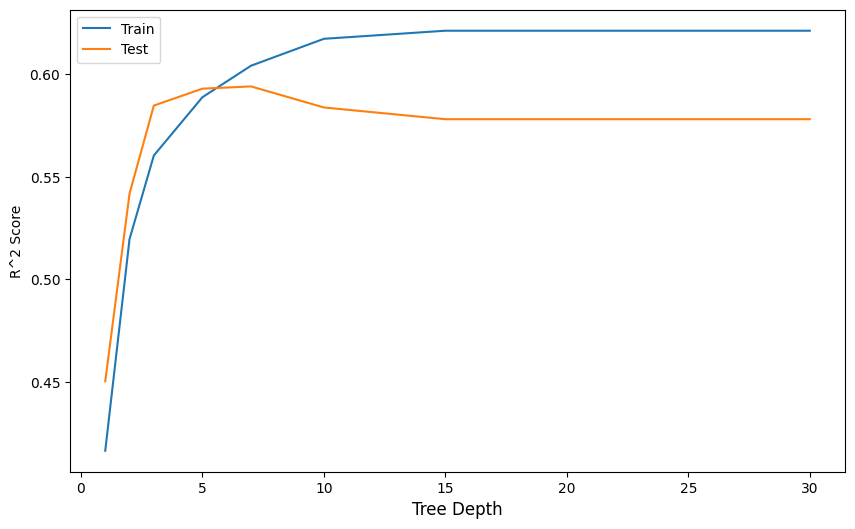

{"depth":{"0":1,"1":2,"2":3,"3":5,"4":7,"5":10,"6":15,"7":20,"8":25,"9":30},"train":{"0":0.4165232341,"1":0.5196985669,"2":0.5604188787,"3":0.5888249718,"4":0.6041716987,"5":0.6172907631,"6":0.6212285845,"7":0.6212285845,"8":0.6212285845,"9":0.6212285845},"test":{"0":0.4503904026,"1":0.5418856179,"2":0.5847461912,"3":0.5929835263,"4":0.5940872453,"5":0.5838230167,"6":0.5780981739,"7":0.5780981739,"8":0.5780981739,"9":0.5780981739}}


In [24]:
#q10
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml import Pipeline
import pandas as pd
import matplotlib.pyplot as plt

depths = [1, 2, 3, 5, 7, 10, 15, 20, 25, 30]
results = []
evaluator = RegressionEvaluator(labelCol="cf_rating", predictionCol="prediction", metricName="r2")

for depth in depths:    
    dt = DecisionTreeRegressor(featuresCol="features", labelCol="cf_rating", maxDepth=depth)
    pipeline = Pipeline(stages=[assembler, dt])
    model = pipeline.fit(train_df)
    train = evaluator.evaluate(model.transform(train_df))
    test = evaluator.evaluate(model.transform(test_df))
    results.append({'depth': depth, 'train': train, 'test': test})
    
df_results = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
plt.plot(df_results['depth'], df_results['train'], label='Train')
plt.plot(df_results['depth'], df_results['test'], label='Test')
plt.xlabel('Tree Depth', fontsize=12)
plt.ylabel('R^2 Score')
plt.legend()
plt.show()
json_str = df_results.to_json()

print(json_str)